# NGNN Node Classification — Fine-Tuned (Cora Dataset)
**Key improvements:**
- AdamW optimizer with tuned weight decay
- CosineAnnealingWarmRestarts scheduler (shorter T_0=50)
- Deeper model: 3 NGNN layers, hidden=128
- BatchNorm instead of LayerNorm (more stable on graphs)
- Dropout=0.6 to fight overfitting
- Separate weights per neutrosophic channel (share_weights=False)
- Early stopping (patience=80)
- Gradient clipping
- Label smoothing loss

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import random
import os
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(42)

In [23]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

print('Nodes:', data.num_nodes)
print('Edges:', data.num_edges)
print('Features:', data.num_node_features)
print('Classes:', dataset.num_classes)

Nodes: 2708
Edges: 10556
Features: 1433
Classes: 7


In [24]:
# 70/15/15 split — same as original
num_nodes = data.num_nodes
indices = torch.randperm(num_nodes)
train_size = int(0.7 * num_nodes)
val_size   = int(0.15 * num_nodes)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[indices[:train_size]] = True
val_mask[indices[train_size:train_size+val_size]] = True
test_mask[indices[train_size+val_size:]] = True

data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

print('Train:', train_mask.sum().item(),
      '| Val:', val_mask.sum().item(),
      '| Test:', test_mask.sum().item())

Train: 1895 | Val: 406 | Test: 407


In [25]:
class NeutrosophicFuzzification(nn.Module):
    """
    Converts raw features into neutrosophic triplets (T, I, F).
    alpha/beta control how spread-out the I and F membership functions are.
    """
    def __init__(self, alpha=0.5, beta=2.0):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta

    def forward(self, x):
        mean = x.mean(dim=0, keepdim=True)
        std  = x.std(dim=0,  keepdim=True) + 1e-6

        T    = torch.exp(-((x - mean)**2) / (2 * std**2))
        F_ns = 1 - torch.exp(-((x - mean)**2) / (2 * (self.alpha * std)**2))
        I    = 1 - torch.exp(-((x - mean)**2) / (2 * (self.beta  * std)**2))

        return torch.stack([T, I, F_ns], dim=2)   # [N, C, 3]

In [26]:
class NGNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels, bias=True):
        super().__init__()
        # Single conv — weights shared across T, I, F
        self.conv = GCNConv(in_channels, out_channels, bias=bias)

    def forward(self, x, edge_index):
        T_out = self.conv(x[:, :, 0], edge_index)
        I_out = self.conv(x[:, :, 1], edge_index)
        F_out = self.conv(x[:, :, 2], edge_index)
        return torch.stack([T_out, I_out, F_out], dim=2)

In [ ]:
class NGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.fuzz = NeutrosophicFuzzification()
        self.dropout = dropout

        self.hidden_channels = hidden_channels          # 128
        self.mid_channels = hidden_channels // 2        # 64
        self.out_channels = out_channels                # 7

        # ---- 3 Layers ----
        self.layer1 = NGNNLayer(in_channels, self.hidden_channels)
        self.layer2 = NGNNLayer(self.hidden_channels, self.mid_channels)
        self.layer3 = NGNNLayer(self.mid_channels, self.out_channels)

        # ---- LayerNorms ----
        self.norm1 = nn.LayerNorm(self.hidden_channels * 3)
        self.norm2 = nn.LayerNorm(self.mid_channels * 3)
        self.norm3 = nn.LayerNorm(self.out_channels * 3)

        # ---- Defuzzification weights ----
        self.rule_weights = nn.Parameter(torch.tensor([1.0, 0.5, 0.5]))

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        num_nodes = x.size(0)

        # ---- Fuzzification ----
        combined = self.fuzz(x)  # [N, in, 3]

        # =========================
        # Layer 1: 1433 → 128
        # =========================
        combined = self.layer1(combined, edge_index)  # [N, 128, 3]

        combined = combined.view(num_nodes, -1)
        combined = self.norm1(combined)
        combined = torch.relu(combined)
        combined = torch.dropout(combined, p=self.dropout, train=self.training)
        combined = combined.view(num_nodes, self.hidden_channels, 3)

        # =========================
        # Layer 2: 128 → 64
        # =========================
        combined = self.layer2(combined, edge_index)  # [N, 64, 3]

        combined = combined.view(num_nodes, -1)
        combined = self.norm2(combined)
        combined = torch.relu(combined)
        combined = torch.dropout(combined, p=self.dropout, train=self.training)
        combined = combined.view(num_nodes, self.mid_channels, 3)

        # =========================
        # Layer 3: 64 → 7
        # =========================
        combined = self.layer3(combined, edge_index)  # [N, 7, 3]

        combined = combined.view(num_nodes, -1)
        combined = self.norm3(combined)
        combined = combined.view(num_nodes, self.out_channels, 3)

        # ---- Defuzzification ----
        weights = torch.softmax(self.rule_weights, dim=0)
        H = (combined * weights).sum(dim=2)  # [N, 7]

        return H, torch.nn.functional.log_softmax(H, dim=1)

In [28]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

model = NGNN(
    in_channels     = dataset.num_node_features,   # 1433
    hidden_channels = 128,
    out_channels    = dataset.num_classes,          # 7
    dropout         = 0.6
).to(device)

data = data.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Device: mps
Trainable parameters: 193,418


In [37]:
# ─── OPTIMIZER ────────────────────────────────────────────────────────────────
# AdamW: decoupled weight decay → fixes overfitting better than plain Adam
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005,
    weight_decay=5e-4   # L2 regularisation on weights
)

# ─── SCHEDULER ────────────────────────────────────────────────────────────────
# CosineAnnealingWarmRestarts:
# - smoothly anneals LR (good for graph message passing)
# - warm restarts help escape local minima
# - T_0=50: restart every 50 epochs (shorter than before → learns faster early on)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0     = 50,
    T_mult  = 2,
    eta_min = 1e-5
)

print('Optimizer : Adam  (lr=0.005, wd=5e-4)')
print('Scheduler : CosineAnnealingWarmRestarts (T0=50, Tmult=2)')

Optimizer : Adam  (lr=0.005, wd=5e-4)
Scheduler : CosineAnnealingWarmRestarts (T0=50, Tmult=2)


In [38]:
# ─── TRAINING LOOP ────────────────────────────────────────────────────────────
EPOCHS          = 500
EARLY_STOP_PAT  = 80      # stop if val acc doesn't improve for 80 epochs

best_val_acc    = 0.0
best_model_state = None
patience_counter = 0

train_losses, train_accs, val_accs = [], [], []

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ──
    model.train()
    optimizer.zero_grad()

    _, out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step(epoch)          # cosine scheduler steps every epoch

    train_losses.append(loss.item())

    # train acc from training-mode output (before no_grad)
    with torch.no_grad():
        tr_pred  = out.argmax(dim=1)
        train_acc = (tr_pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
    train_accs.append(train_acc)

    # ── VALIDATE ──
    model.eval()
    with torch.no_grad():
        _, val_out = model(data)
        pred       = val_out.argmax(dim=1)
        val_acc    = (pred[data.val_mask] == data.y[data.val_mask]).float().mean().item()
    val_accs.append(val_acc)

    # ── SAVE BEST ──
    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

   

    if epoch % 20 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d} | Loss: {loss.item():.4f} | '
              f'Train: {train_acc:.4f} | Val: {val_acc:.4f} | LR: {lr:.2e}')

Epoch  20 | Loss: 0.0211 | Train: 0.9910 | Val: 0.8079 | LR: 3.28e-03
Epoch  40 | Loss: 0.0145 | Train: 0.9963 | Val: 0.8153 | LR: 4.87e-04
Epoch  60 | Loss: 0.0252 | Train: 0.9916 | Val: 0.8276 | LR: 4.88e-03
Epoch  80 | Loss: 0.0340 | Train: 0.9858 | Val: 0.7931 | LR: 3.97e-03
Epoch 100 | Loss: 0.0357 | Train: 0.9873 | Val: 0.8128 | LR: 2.51e-03
Epoch 120 | Loss: 0.0253 | Train: 0.9921 | Val: 0.8128 | LR: 1.04e-03
Epoch 140 | Loss: 0.0221 | Train: 0.9926 | Val: 0.8202 | LR: 1.32e-04
Epoch 160 | Loss: 0.0372 | Train: 0.9884 | Val: 0.8202 | LR: 4.97e-03
Epoch 180 | Loss: 0.0358 | Train: 0.9884 | Val: 0.8251 | LR: 4.73e-03
Epoch 200 | Loss: 0.0416 | Train: 0.9863 | Val: 0.8350 | LR: 4.27e-03
Epoch 220 | Loss: 0.0366 | Train: 0.9868 | Val: 0.8350 | LR: 3.64e-03
Epoch 240 | Loss: 0.0358 | Train: 0.9868 | Val: 0.8202 | LR: 2.90e-03
Epoch 260 | Loss: 0.0266 | Train: 0.9900 | Val: 0.8202 | LR: 2.11e-03
Epoch 280 | Loss: 0.0287 | Train: 0.9900 | Val: 0.8325 | LR: 1.37e-03
Epoch 300 | Loss: 0.

In [39]:
# ─── TEST WITH BEST CHECKPOINT ────────────────────────────────────────────────
if best_model_state:
    model.load_state_dict(best_model_state)

model.eval()
with torch.no_grad():
    _, out = model(data)
    pred   = out.argmax(dim=1)
    test_acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item()

print(f'\nBest Val Accuracy  : {best_val_acc:.4f}')
print(f'Final Test Accuracy: {test_acc:.4f}')


Best Val Accuracy  : 0.8424
Final Test Accuracy: 0.8452


In [40]:
# ─── FULL METRICS ─────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    _, out = model(data)
    pred   = out.argmax(dim=1).cpu()
    true   = data.y.cpu()

y_true = true[data.test_mask.cpu()]
y_pred = pred[data.test_mask.cpu()]

acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)
cm        = confusion_matrix(y_true, y_pred)

print(f'Test Accuracy  : {acc:.4f}')
print(f'Test Precision : {precision:.4f}')
print(f'Test Recall    : {recall:.4f}')
print(f'Test F1 Score  : {f1:.4f}')
print('\nConfusion Matrix:')
print(cm)

Test Accuracy  : 0.8452
Test Precision : 0.8405
Test Recall    : 0.8349
Test F1 Score  : 0.8348

Confusion Matrix:
[[ 39   1   0   3   5   0   1]
 [  1  27   0   0   0   3   0]
 [  1   2  58   2   0   0   0]
 [  4   3   2 101   6   1   1]
 [  6   1   0   4  55   3   0]
 [  1   0   1   3   0  45   0]
 [  4   0   0   1   0   3  19]]


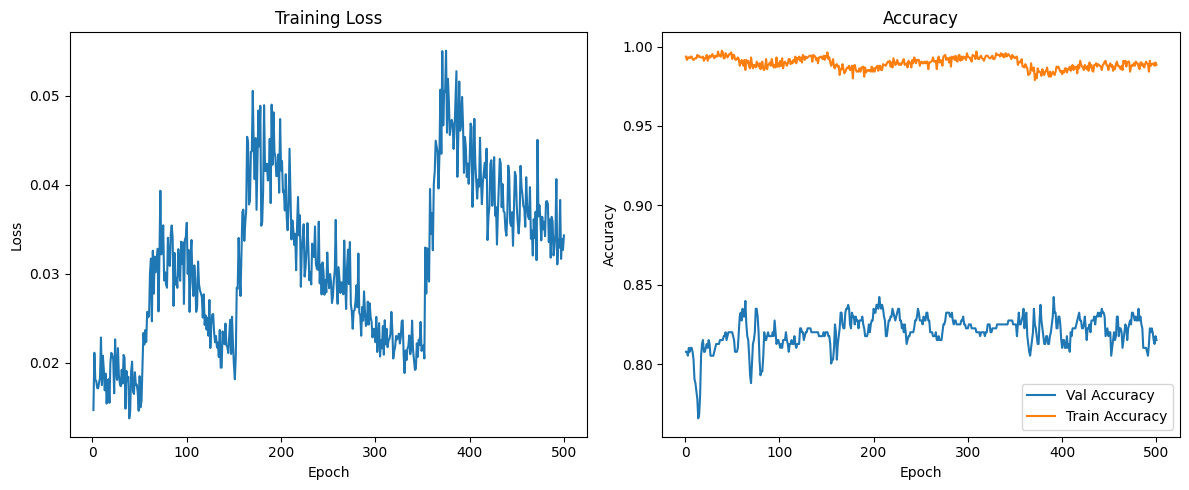

In [41]:
# ─── PLOTS ────────────────────────────────────────────────────────────────────
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(epochs, val_accs,   label='Val Accuracy')
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
# ─── WRONG PREDICTIONS ANALYSIS ───────────────────────────────────────────────
model.eval()
with torch.no_grad():
    _, out = model(data)
    pred = out.argmax(dim=1)

test_idx  = data.test_mask.nonzero(as_tuple=True)[0]
y_true    = data.y[test_idx]
y_pred    = pred[test_idx]

wrong_mask = (y_true != y_pred)
total_wrong = wrong_mask.sum().item()
total_test  = test_idx.size(0)

print(f"Total test nodes     : {total_test}")
print(f"Correctly predicted  : {total_test - total_wrong}")
print(f"Wrongly predicted    : {total_wrong}")
print(f"Accuracy             : {(total_test - total_wrong) / total_test:.4f}")

# Optional: list each misclassified node
print("\nMisclassified nodes (Node ID | Predicted → Actual):")
wrong_idx = test_idx[wrong_mask]
for node in wrong_idx:
    i = (test_idx == node).nonzero(as_tuple=True)[0].item()
    print(f"  Node {node.item():4d} : Pred={y_pred[i].item()} → Actual={y_true[i].item()}")

Total test nodes     : 407
Correctly predicted  : 344
Wrongly predicted    : 63
Accuracy             : 0.8452

Misclassified nodes (Node ID | Predicted → Actual):
  Node   21 : Pred=5 → Actual=3
  Node   54 : Pred=0 → Actual=1
  Node   86 : Pred=0 → Actual=4
  Node  162 : Pred=0 → Actual=4
  Node  176 : Pred=5 → Actual=1
  Node  210 : Pred=0 → Actual=4
  Node  221 : Pred=3 → Actual=2
  Node  285 : Pred=6 → Actual=3
  Node  293 : Pred=4 → Actual=3
  Node  304 : Pred=3 → Actual=0
  Node  332 : Pred=4 → Actual=3
  Node  376 : Pred=2 → Actual=5
  Node  377 : Pred=4 → Actual=3
  Node  474 : Pred=3 → Actual=5
  Node  530 : Pred=1 → Actual=0
  Node  543 : Pred=4 → Actual=0
  Node  545 : Pred=3 → Actual=4
  Node  551 : Pred=5 → Actual=6
  Node  674 : Pred=4 → Actual=3
  Node  682 : Pred=5 → Actual=6
  Node  684 : Pred=1 → Actual=2
  Node  702 : Pred=0 → Actual=6
  Node  776 : Pred=3 → Actual=4
  Node  849 : Pred=3 → Actual=4
  Node  885 : Pred=3 → Actual=5
  Node  921 : Pred=0 → Actual=6
  Nod